# Time Series Forecasting of Stock Market with ARIMA

### Stock Data Scraping

In [40]:
# import libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import yfinance as yf
import datetime as dt
from datetime import date, timedelta
import plotly.graph_objects as go
import plotly.express as px

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [41]:
# Define dates to fetch data
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = (today - timedelta(days=365)).strftime("%Y-%m-%d")
start_date = d2
print("Data from", start_date, "to", end_date)

Data from 2024-11-28 to 2025-11-28


In [42]:
# define ticker
ticker = '^NSEI'

df = yf.download(ticker, start=start_date, end=end_date, progress=False)
df.head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18716\1111517151.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2024-11-28,23914.150391,24345.750000,23873.349609,24274.150391,366700
2024-11-29,24131.099609,24188.449219,23927.150391,23927.150391,282100
2024-12-02,24276.050781,24301.699219,24008.650391,24140.849609,220400
2024-12-03,24457.150391,24481.349609,24280.000000,24367.500000,339500
2024-12-04,24467.449219,24573.199219,24366.300781,24488.750000,348000


In [43]:
df.insert(0, 'Date', df.index)

In [44]:
df.reset_index(drop=True, inplace=True)
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
0,2024-11-28,23914.150391,24345.750000,23873.349609,24274.150391,366700
1,2024-11-29,24131.099609,24188.449219,23927.150391,23927.150391,282100
2,2024-12-02,24276.050781,24301.699219,24008.650391,24140.849609,220400
3,2024-12-03,24457.150391,24481.349609,24280.000000,24367.500000,339500
4,2024-12-04,24467.449219,24573.199219,24366.300781,24488.750000,348000


In [45]:
# Flatten the MultiIndex columns: keep only the first level
df.columns = df.columns.get_level_values(0)

# make sure we keep only these columns and in this order
df = df[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]

print(df.head())

Price       Date         Close          High           Low          Open  \
0     2024-11-28  23914.150391  24345.750000  23873.349609  24274.150391   
1     2024-11-29  24131.099609  24188.449219  23927.150391  23927.150391   
2     2024-12-02  24276.050781  24301.699219  24008.650391  24140.849609   
3     2024-12-03  24457.150391  24481.349609  24280.000000  24367.500000   
4     2024-12-04  24467.449219  24573.199219  24366.300781  24488.750000   

Price  Volume  
0      366700  
1      282100  
2      220400  
3      339500  
4      348000  


In [46]:
fig = px.line(df, x='Date', y=df.columns, title=f'{ticker} Plot')
fig.show()

In [47]:
df = df[['Date', 'Close']]
df.head()

Price,Date,Close
0,2024-11-28,23914.150391
1,2024-11-29,24131.099609
2,2024-12-02,24276.050781
3,2024-12-03,24457.150391
4,2024-12-04,24467.449219


In [48]:
# plot the closing price
fig = px.line(df, x='Date', y='Close', title=f'{ticker} Closing Prices')
fig.show()

In [49]:
# Stationarity Test - Augmented Dickey-Fuller Test
from statsmodels.tsa.stattools import adfuller
def check_stationarity(df):
    result = adfuller(df)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("Data is stationary.")
    else:
        print("Data is non-stationary.")

check_stationarity(df['Close'])

ADF Statistic: -0.8977101232388601
p-value: 0.7887255715642758
Data is non-stationary.


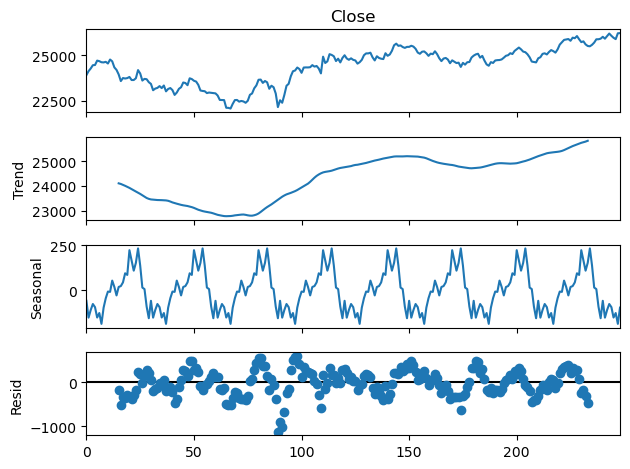

In [50]:
# Decompose data to see trend, seasonality and noise
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], model='additive', period=30)
fig = decomposition.plot()
plt.show()

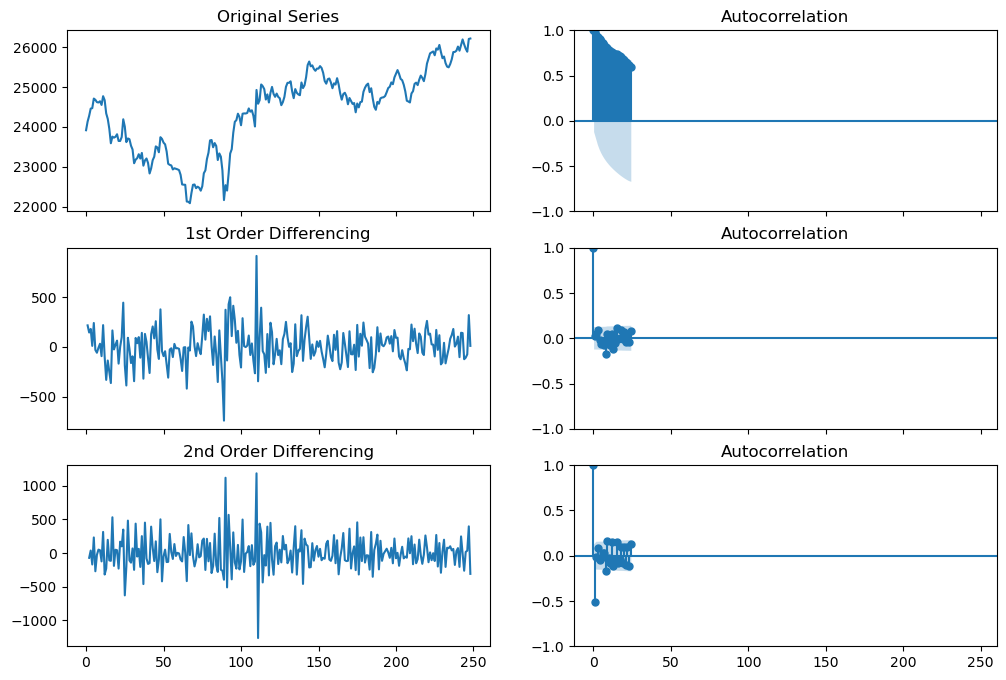

In [51]:
# Autocorrelation and Partial Autocorrelation Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3,2, figsize=(12,8), sharex=True)
axes[0,0].plot(df['Close']); axes[0,0].set_title('Original Series')
plot_acf(df['Close'], ax=axes[0,1])

# 1st Differencing
axes[1,0].plot(df['Close'].diff()); axes[1,0].set_title('1st Order Differencing')
plot_acf(df['Close'].diff().dropna(), ax=axes[1,1])

# 2nd Differencing
axes[2,0].plot(df['Close'].diff().diff()); axes[2,0].set_title('2nd Order Differencing')
plot_acf(df['Close'].diff().diff().dropna(), ax=axes[2,1])

plt.show()

#### As there is not much difference between 1 & 2, we can use `d=1`, because d=2 would require extra computation.

## `P` value

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

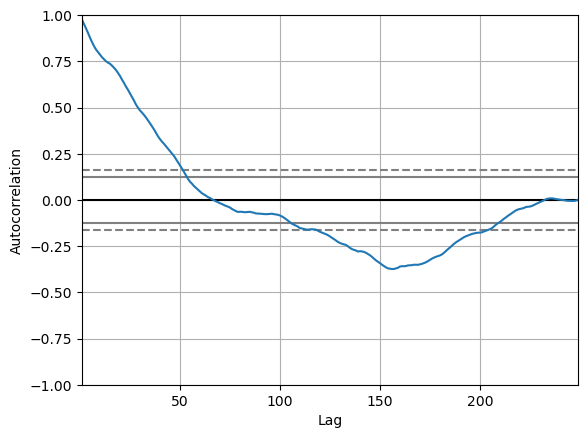

In [52]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
pd.plotting.autocorrelation_plot(df['Close'])

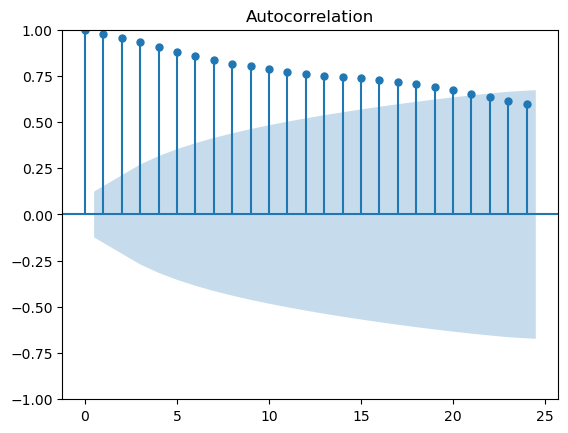

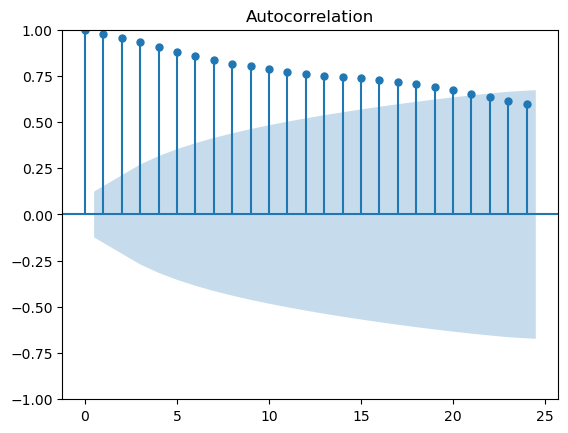

In [53]:
plot_acf(df['Close'], alpha=0.05)

In [54]:
from statsmodels.tsa.stattools import acf, pacf
x_acf = pd.DataFrame(acf(df['Close']))
print(x_acf)

           0
0   1.000000
1   0.976795
2   0.953287
3   0.930797
4   0.905088
5   0.879355
6   0.855243
7   0.833333
8   0.814806
9   0.801076
10  0.786438
11  0.772885
12  0.762005
13  0.750548
14  0.742941
15  0.737244
16  0.727047
17  0.715740
18  0.703351
19  0.688044
20  0.671665
21  0.651926
22  0.633919
23  0.613926


## p = 2

## `q` Value

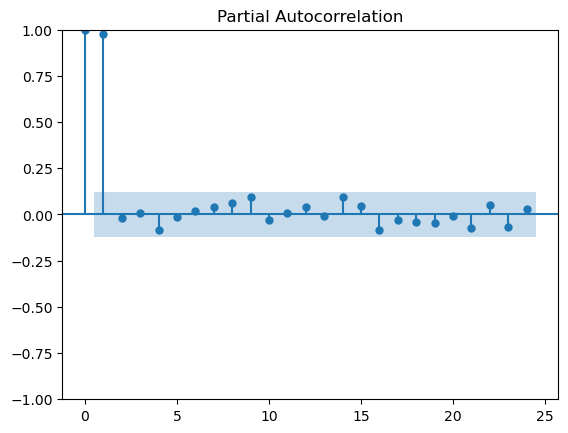

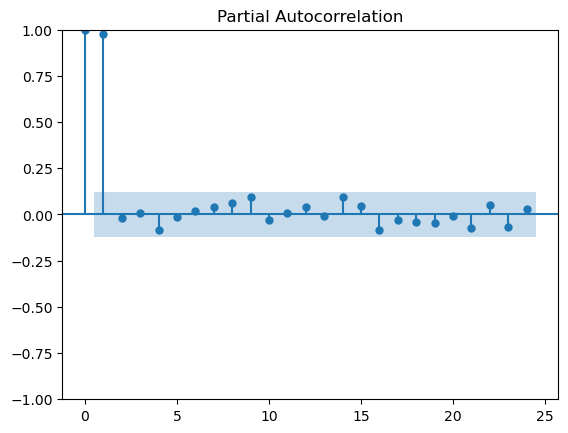

In [55]:
# partial autocorrelation plot
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['Close'], alpha=0.05)

# q = 2

In [56]:
p = 2
q = 2
d = 1

In [57]:
pip install pmdarima

In [58]:
# lets run ARIMA model with pmdarima
from pmdarima.arima import auto_arima

model = auto_arima(df['Close'], start_p=1, start_q=1, max_p=2, max_q=2, m=12, seasonal=True, trace=True, d=1, D=1, error_action='ignore', suppress_warnings=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=inf, Time=1.83 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=3283.639, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=3208.208, Time=0.23 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=0.41 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=3279.497, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=3193.701, Time=0.63 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=2.54 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.22 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=3193.984, Time=0.19 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=3194.546, Time=0.63 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=inf, Time=3.00 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=3193.957, Time=0.56 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AIC=inf, Time=2.30 sec
 ARIMA(1,1,0)(2,1,0)[12] intercept   : AIC=3195.700, Time=0.87 sec

Best model:  ARIMA(1,1,0)(2,1,0)[12]          
T

In [59]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  249
Model:             SARIMAX(1, 1, 0)x(2, 1, 0, 12)   Log Likelihood               -1592.850
Date:                            Fri, 28 Nov 2025   AIC                           3193.701
Time:                                    17:06:54   BIC                           3207.556
Sample:                                         0   HQIC                          3199.286
                                            - 249                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0930      0.048      1.953      0.051      -0.000       0.186
ar.S.L12      -0.6346      0.048   

In [60]:
model = auto_arima(df['Close'], seasonal=True, suppress_warnings=True)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  249
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -1642.430
Date:                Fri, 28 Nov 2025   AIC                           3286.859
Time:                        17:06:55   BIC                           3290.373
Sample:                             0   HQIC                          3288.274
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      3.311e+04   1899.353     17.431      0.000    2.94e+04    3.68e+04
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                87.88
Prob(Q):                              0.72   Pr

In [61]:
# statsmodel and arima
from statsmodels.tsa.arima.model import ARIMA

p, d, q = 2, 1, 2
model = ARIMA(df['Close'], order=(p,d,q))
model = model.fit()
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  249
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1636.659
Date:                Fri, 28 Nov 2025   AIC                           3283.318
Time:                        17:06:56   BIC                           3300.885
Sample:                             0   HQIC                          3290.390
                                - 249                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1791      0.044     26.719      0.000       1.093       1.266
ar.L2         -0.8911      0.046    -19.569      0.000      -0.980      -0.802
ma.L1         -1.2266      0.291     -4.217      0.0

c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [62]:
# predict next 30 days
forecast = model.predict(len(df['Close']), len(df['Close'])+30)
print(forecast)

249    26174.883594
250    26171.979827
251    26204.794668
252    26246.075189
253    26265.508791
254    26251.638228
255    26217.965640
256    26190.621425
257    26188.384879
258    26210.114284
259    26237.729072
260    26250.927297
261    26241.882024
262    26219.455461
263    26201.071925
264    26199.379787
265    26213.766208
266    26232.237541
267    26241.197818
268    26235.303240
269    26220.368214
270    26208.010571
271    26206.747992
272    26216.271212
273    26228.625416
274    26234.706432
275    26230.867838
276    26220.922810
277    26212.616923
278    26211.685276
279    26217.988164
Name: predicted_mean, dtype: float64


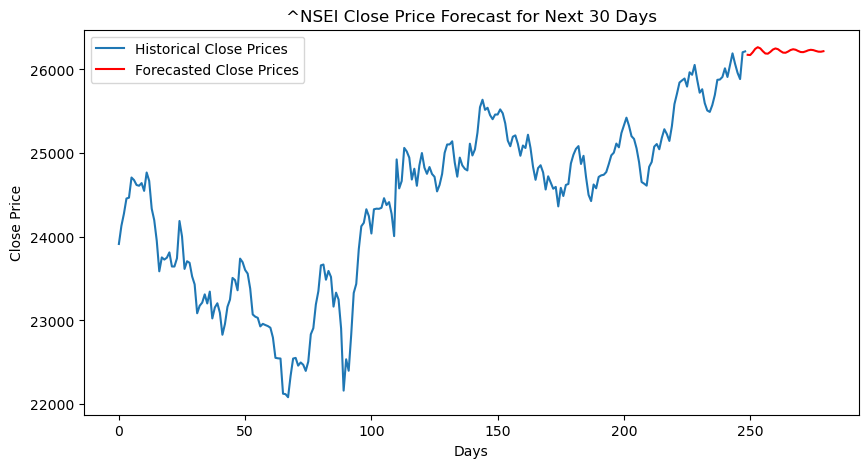

In [63]:
# plot the forecasted values
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Historical Close Prices')
plt.plot(forecast, label='Forecasted Close Prices', color='red')
plt.title(f'{ticker} Close Price Forecast for Next 30 Days')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## Running SARIMA

In [64]:
import statsmodels.api as sm
import warnings

p, d, q = 2, 1, 2
model = sm.tsa.statespace.SARIMAX(df['Close'], order=(p,d,q), seasonal_order=(p,d,q,12))
model = model.fit()
print(model.summary())

c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



                                     SARIMAX Results                                      
Dep. Variable:                              Close   No. Observations:                  249
Model:             SARIMAX(2, 1, 2)x(2, 1, 2, 12)   Log Likelihood               -1576.220
Date:                            Fri, 28 Nov 2025   AIC                           3170.440
Time:                                    17:07:01   BIC                           3201.614
Sample:                                         0   HQIC                          3183.007
                                            - 249                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3570     35.129     -0.010      0.992     -69.208      68.494
ar.L2          0.6426     22.601   

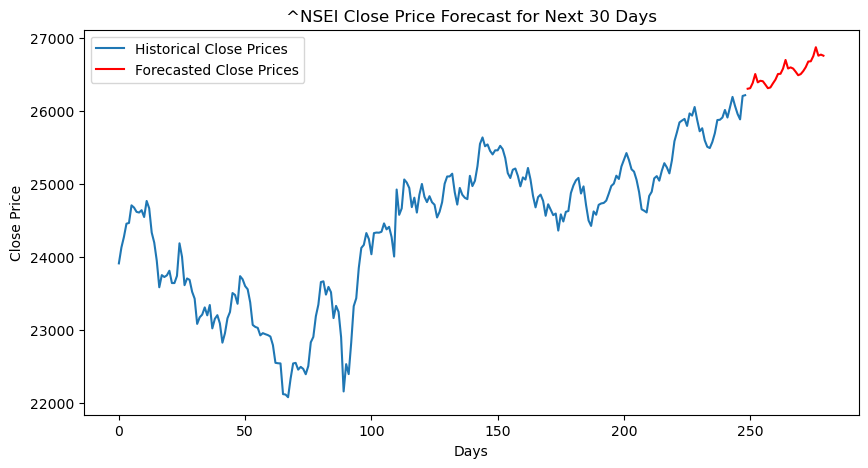

In [65]:
predictions = model.predict(len(df['Close']), len(df['Close'])+30)

# plot the forecasted values
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Historical Close Prices')
plt.plot(predictions, label='Forecasted Close Prices', color='red')
plt.title(f'{ticker} Close Price Forecast for Next 30 Days')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## Hyperparameter Tuning

In [66]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import itertools

# Defining p,d,q between 0 and 2
p = d = q = range(0, 2)

# Generating all different combinations of p, d and q triplets
pdq = list(itertools.product(p, d, q))

# Generating all different combinations of seasonal p, d, q and m quadriplets
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

for param in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            temp_model = SARIMAX(df['Close'], order=param, seasonal_order=seasonal_param, enforce_stationarity=False, enforce_invertibility=False)
            results = temp_model.fit()
            if results.aic < best_aic:
                best_aic = results.aic
                best_pdq = param
                best_seasonal_pdq = seasonal_param
        except:
            continue

print('Best SARIMA{}x{}12 model - AIC:{}'.format(best_pdq, best_seasonal_pdq, best_aic))

# Predict next 30 days using the best model
model = SARIMAX(df['Close'], order=best_pdq, seasonal_order=best_seasonal_pdq, enforce_stationarity=False, enforce_invertibility=False)
model = model.fit()
predictions = model.predict(len(df['Close']), len(df['Close'])+30)
print(predictions)

c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Best SARIMA(0, 1, 1)x(1, 1, 1, 12)12 model - AIC:2957.9940000730494
249    26294.238979
250    26295.011880
251    26360.116074
252    26438.942868
253    26305.929595
254    26325.078486
255    26314.545662
256    26268.305834
257    26217.868749
258    26229.029761
259    26279.875154
260    26331.423052
261    26406.498367
262    26407.170208
263    26473.615885
264    26551.478972
265    26417.304197
266    26431.611315
267    26415.194160
268    26372.004109
269    26323.850166
270    26338.378641
271    26378.648103
272    26431.815716
273    26506.749332
274    26507.417210
275    26573.915500
276    26651.740791
277    26517.520461
278    26531.637684
279    26514.989743
Name: predicted_mean, dtype: float64


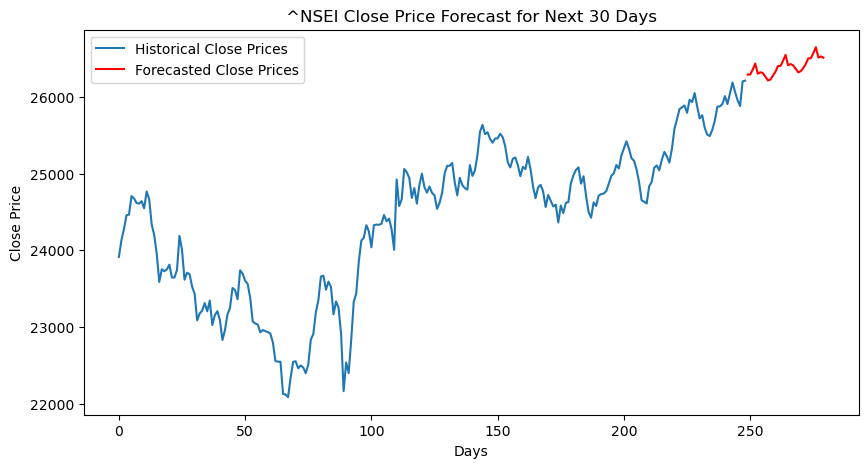

In [67]:
# plot the forecasted values
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Historical Close Prices')
plt.plot(predictions, label='Forecasted Close Prices', color='red')
plt.title(f'{ticker} Close Price Forecast for Next 30 Days')
plt.xlabel('Days')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [68]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Close   No. Observations:                  249
Model:             SARIMAX(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1474.997
Date:                            Fri, 28 Nov 2025   AIC                           2957.994
Time:                                    17:07:22   BIC                           2971.605
Sample:                                         0   HQIC                          2963.489
                                            - 249                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0082      0.055      0.149      0.881      -0.100       0.116
ar.S.L12       0.0392      0.030      1.322      0.186      -0.019       0.097
ma.S.L12      -0.9999      0.061    -16.366      0.000      -1.120      -0.880
sigma2      3.046e+04   2.01e-06   1.52e+10      0.000    3.05e+04    3.05e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                76.75
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.44   Skew:                             0.52
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 8.1e+24. Standard errors may be unstable.
"""